# 5. Parallelism


In [1]:
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.types import Command
from langgraph.types import Send
from typing import TypedDict, Literal
from typing_extensions import Annotated
import operator

Define the model

In [2]:
llm = AzureChatOpenAI(model="gpt-4.1-mini")

Since we will be running items in parallel, we will need to store the output of each node in a state. Therefore we need to define an object that will store those items in memory. 

Notice though that we make use of the operator.add, this is an easier way to extend a list variable.

In [3]:
class OurCustomState(TypedDict):
    cities: list[str]
    facts: Annotated[list, operator.add]


class CityState(TypedDict):
    city: str

A node/agent that will give us advice about a city

In [4]:
def city_advice(state: CityState) -> str:
    print("Node: CityAdvice")
    response = llm.invoke(
        input=[
            HumanMessage(
                content=f"Tell me 3 interesting facts about {state['city']}. "
                "Only return the facts, no other text. Use a numbered list."
                "Start with the city name. Ex. # CityName"
            )
        ]
    )

    return {"facts": [response.content]}

A node/agent that will return random cities.

And will execute the city advice node for each one of them. 

Notice we return a Command with goto, this also means when we built or graph we do not need to make a link between the two.

In [5]:
def random_city_generator(
    state: OurCustomState,
) -> Command[Literal["city_advice", "final_node"]]:
    print("Node: Random City Generator")
    response = llm.invoke(
        input="Return 3 random city names in Finland, comma separated."
    )
    cities = response.content.split(",")
    if len(cities) > 0:
        return Command(
            update={"cities": cities},
            goto=[
                Send(node="city_advice", arg={"city": city.strip()}) for city in cities
            ],
        )
    else:
        return Command(update={"cities": []}, goto=["final_node"])

A final node purely for demonstration purposes to print the collected info

In [6]:
def final_node(state: OurCustomState):
    print("Node: Final")
    print("Cities:", state["cities"])
    print("Facts:", state["facts"])
    return {}

Setting up a langgraph graph.

Notice that there is no link between random_city_generator and city_advice. Not needed because of the goto.

In [7]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(OurCustomState)

builder.add_node("random_city_generator", random_city_generator)
builder.add_node("city_advice", city_advice)
builder.add_node("final_node", final_node)

builder.add_edge(START, "random_city_generator")
builder.add_edge("city_advice", "final_node")
builder.add_edge("final_node", END)
graph = builder.compile()

Printing out the workflow diagram

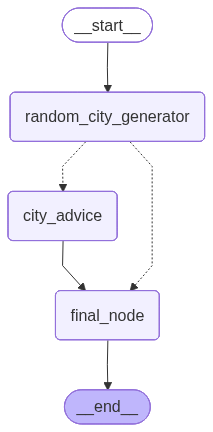

In [8]:
from IPython.display import Image

Image(graph.get_graph(xray=1).draw_mermaid_png())

Executing the workflow

In [9]:
state = graph.invoke(input={})

Node: Random City Generator
Node: CityAdviceNode: CityAdvice

Node: CityAdvice
Node: Final
Cities: ['Helsinki', ' Tampere', ' Turku']
Facts: ['# Helsinki  \n1. Helsinki was originally founded in 1550 by King Gustav I of Sweden as a trading town to compete with the Hanseatic city of Reval (now Tallinn).  \n2. The Helsinki Cathedral, an iconic landmark, was designed by Carl Ludvig Engel and completed in 1852, featuring neoclassical architecture that dominates Senate Square.  \n3. Helsinki is known as the "Daughter of the Baltic Sea" and is surrounded by over 300 islands, making it a city deeply connected to maritime culture and nature.', '# Tampere  \n1. Tampere is known as the "Manchester of Finland" due to its historical role as a major industrial hub, particularly in textiles and metalworking.  \n2. The city is home to the world\'s first-ever Finnish sauna museum, Sauna from Finland, showcasing the cultural significance of sauna in Finnish life.  \n3. Tampere boasts a unique location 

Printing out the fields in the earlier defined output

In [10]:
for fact in state["facts"]:
    print(fact)

# Helsinki  
1. Helsinki was originally founded in 1550 by King Gustav I of Sweden as a trading town to compete with the Hanseatic city of Reval (now Tallinn).  
2. The Helsinki Cathedral, an iconic landmark, was designed by Carl Ludvig Engel and completed in 1852, featuring neoclassical architecture that dominates Senate Square.  
3. Helsinki is known as the "Daughter of the Baltic Sea" and is surrounded by over 300 islands, making it a city deeply connected to maritime culture and nature.
# Tampere  
1. Tampere is known as the "Manchester of Finland" due to its historical role as a major industrial hub, particularly in textiles and metalworking.  
2. The city is home to the world's first-ever Finnish sauna museum, Sauna from Finland, showcasing the cultural significance of sauna in Finnish life.  
3. Tampere boasts a unique location between two large lakes, Näsijärvi and Pyhäjärvi, offering scenic waterfronts and numerous outdoor activities year-round.
# Turku  
1. Turku is the oldes